# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
from sklearn.cluster import KMeans
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
image = plt.imread('data/ejer_kmeans.png')
image.shape

(764, 1499, 3)

In [3]:
# pa coscarme y recordar:
# imagen es una matriz "3D"de num
# 1a dimensión: alto (num filas de pix)
# 2a dim: ancho (num cols de pix)
# 3a dim: 3 canales de color (RGB) 0-255

# con k-means es decirle algo así como que se olvide de todos esos colores y se quede solo con k 

# en este caso:
# 764 px alto
# 1499 px ancho
# 3 los canales di colori

Muestra la imagen para ver que se ha cargado bien

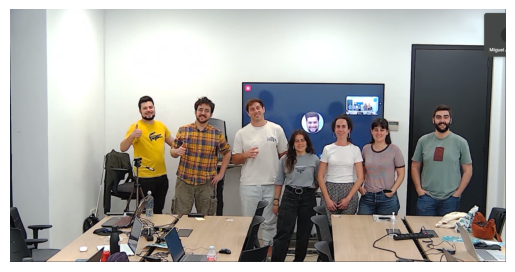

In [4]:
plt.imshow(image)
plt.axis('off');

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [5]:
# k-means necesita que cada observación sea una fila en una table
# en este caso cada pixel es una observación y ekl canal de 3 valores RGB son las features
# pasamos a una matriz 2D

In [6]:
# Guardamos las dimensiones originales — las necesitaremos más adelante para reconstruir la imagen
alto, ancho, canales = image.shape

# miro el total de pix
pixels = alto*ancho
print(f'total pixels: {pixels}')

# con reshape(-1, 3) aplano las 2 primeras dim (alto*ancho) en una sola
# con el -1 le digo a numpy: "calcula tú cuántas filas necesito"
# con el 3 mantengo los 3 canales de color como columnas
image_2d = image.reshape(-1, 3)

print(f'3D: {image.shape}')
print(f'2D: {image_2d.shape}')

print(f'\nprimeros 5 píxeles (valores RGB):')
print(image_2d[:5])

total pixels: 1145236
3D: (764, 1499, 3)
2D: (1145236, 3)

primeros 5 píxeles (valores RGB):
[[0.5686275  0.5803922  0.61960787]
 [0.5529412  0.5647059  0.6039216 ]
 [0.54901963 0.5686275  0.6039216 ]
 [0.5568628  0.5764706  0.6117647 ]
 [0.5568628  0.57254905 0.6117647 ]]


In [7]:
# salen números peques porque matplotlib.imread normaliza automáticamente los valores de los
# píxeles entre 0 y 1 cuando la imagen es PNG
# si la imagen es JPG sí devuelve valores entre 0 y 255

# puedo convertirlos así:
print((image_2d[:5] * 255).astype(int))

[[145 148 158]
 [141 144 154]
 [140 145 154]
 [142 147 156]
 [142 146 156]]


In [8]:
# eso era para mi TOC, porque luego para k-means usaré lo que me salió de primeras

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [9]:
# aplicamos k-means sobre los píxeles
# k es el num de colores que quiero en la imagen final

# elige k puntos random como centroides (cada centroide es un color RGB)
# entiendo que asignará cada píxel al centroide/color más cercano
# recalculará cada centroide como el color promedio de todos los píxeles de su grupo

# por ejemplo, con K=8 reduzco la imagen a solo 8 colores

In [11]:
# lista de valores de K que quiero probar
ks = [2, 4, 8, 16] # cada k representa cuántos colores tendrá la imagen final

# guardo los modelos, los centroides y la inercia para cada k
modelos = []
centroides_por_k = []
inertias = []

for K in ks:
    print(f'\nK={K}')
    kmeans = KMeans(n_clusters=K, # num de colores
                    n_init=10, # repite 10 veces
                    random_state=42)

    kmeans.fit(image_2d) # entreno el modelo con todos los píxeles de la imagen, cada pix tiene RGB
    
    modelos.append(kmeans) # guardo el modelo entrenado
    
    centroides_por_k.append(kmeans.cluster_centers_) # guardo los centroides (los K colores finales)
    
    inertias.append(kmeans.inertia_) # guardo inercia (suma de distancias de cada píxel a su centroide)
    
    print(f"primeros centroides:\n{ kmeans.cluster_centers_[:5] }")


K=2
primeros centroides:
[[0.8373754  0.8360944  0.81000006]
 [0.29818523 0.28165197 0.28102276]]

K=4
primeros centroides:
[[0.7334904  0.71296775 0.67907053]
 [0.17302808 0.17068782 0.18853268]
 [0.9291613  0.9464425  0.92861605]
 [0.477098   0.43866843 0.40986693]]

K=8
primeros centroides:
[[0.82704806 0.8397476  0.8209233 ]
 [0.27446887 0.24944544 0.24767834]
 [0.54404104 0.48578566 0.45721665]
 [0.95714563 0.97452503 0.9577779 ]
 [0.10057992 0.09515041 0.10361925]]

K=16
primeros centroides:
[[0.76150507 0.76693356 0.7537995 ]
 [0.23918661 0.24776733 0.26494747]
 [0.9140748  0.9392397  0.91602707]
 [0.77169204 0.6749371  0.58208823]
 [0.23306596 0.33597806 0.49554372]]


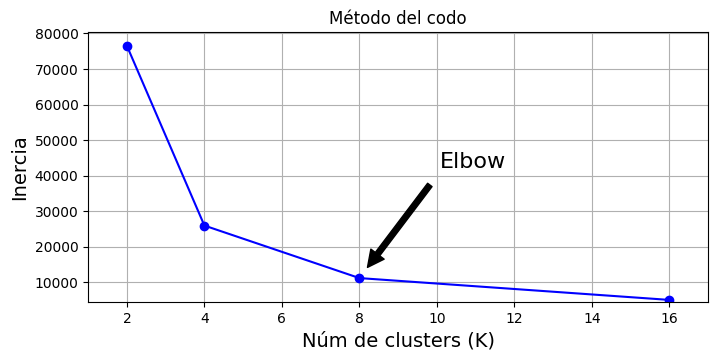

In [55]:
# el codo
# así veocómo disminuye la inercia (suma de distancias de cada píxel a su centroide)
# a medida que aumento el num dek

plt.figure(figsize=(8, 3.5))
plt.plot(ks, inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.annotate('Elbow', # elbow es el punto donde la inercia sigue bajando, pero lo hace más lentamente
             xy=(ks[2], inertias[2]), # punto donde marco el codo
             xytext=(0.55, 0.55),# posición del texto en coordenadas relativas
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.xlabel('Núm de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.axis([min(ks)-1, max(ks)+1, min(inertias)*0.9, max(inertias)*1.05])
plt.show()

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [15]:
# aquí reconstruyo la imagen utilizando los resultados de k-means

# cada píxel original se sustituye por el color de su centroide
# como imágenes sonmatrices numéricas, indexo los centroides usando las etiquetas
# para obtener una nueva matriz de píxeles

K_elegido = 16 # elijo el modelo correspondiente al k que quiero reconstruir
idx = ks.index(K_elegido)

kmeans = modelos[idx]
centroides = centroides_por_k[idx]
labels = kmeans.labels_ # labels_ indica para cada píxel a qué cluster (color) pertenece

image_reconstruida_2d = centroides[labels] # sustituyo cada píxel por su centroide correspondiente

print(image_reconstruida_2d.shape) 

(1145236, 3)


#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [16]:
# devuelvo la imagen a su forma original (alto, ancho, 3) para visualizarla
image_reconstruida = image_reconstruida_2d.reshape(alto, ancho, canales) # devuelvo la imagen a su forma original

print(image_reconstruida.shape)

(764, 1499, 3)


#### 7. Muestra y guarda en tu ordenador la imagen resultante

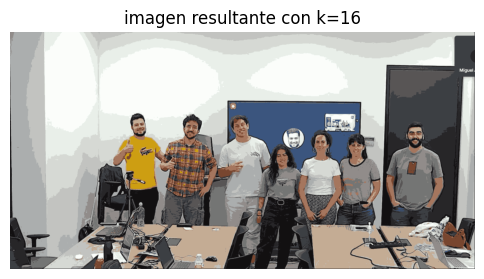

In [17]:
plt.figure(figsize=(6, 6))
plt.imshow(image_reconstruida)
plt.axis("off")
plt.title(f"imagen resultante con k={K_elegido}")
plt.show()


In [59]:
# plt.imsave almacena la matriz de la imagen en PNG

plt.imsave("data/imagen_k16.png", image_reconstruida)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [60]:
def kmeans_imagen(imagen, K=8, mostrar=True, guardar=False, nombre_salida="imagen_kmeans.png"):
    '''
    aplica k-means a una imagen para reducirla a k colores
    imagen: array (alto, ancho, 3)
    K: int, num colores deseados para la imagen resultante
    mostrar : bool, muestra la imagen por pantalla
    guardar : bool, guarda la imagenen disco
    nombre_salida : str, nombre del PNG a guardar
    '''
    
    alto, ancho, canales= imagen.shape # guardo laforma original
    
    imagen_2d = imagen.reshape(-1, 3) # aplano la image
    
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=42) # aquí entreno el k-means
    kmeans.fit(imagen_2d)

    labels = kmeans.labels_ # aquí sustituyo píx x centroide
    centroides = kmeans.cluster_centers_
    imagen_simple_2d = centroides[labels]

    imagen_simple = imagen_simple_2d.reshape(alto, ancho, canales) # reconstruyo la imagen

    if mostrar: # muestro la img
        plt.figure(figsize=(6, 6))
        plt.imshow(imagen_simple)
        plt.axis("off")
        plt.title(f"imagen resultante con K={K}")
        plt.show()

    if guardar: # guardo
        plt.imsave(nombre_salida, imagen_simple)
        print(f"img guardada como '{nombre_salida}'")

    return imagen_simple

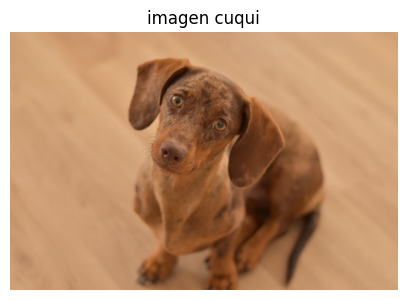

In [61]:
# vamo a probarla

imagen_cuqui = plt.imread("data/sena.png")

plt.figure(figsize=(5,5))
plt.imshow(imagen_cuqui)
plt.axis("off")
plt.title("imagen cuqui")
plt.show()


In [64]:
imagen_cuqui.shape

(1066, 1600, 4)

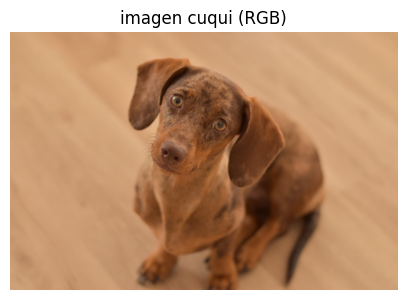

In [67]:
from PIL import Image

# cargo la imagen y la convierto a RGB (quita el canal alfa)
# la IA me dice que tiene 4 canales: una imagen RGBA (RGB + canal alfa)
# como k-means solo funciona con 3 canales, tengpque convertirla a RGB

img = Image.open("data/sena.png").convert("RGB")
imagen_cuqui = np.array(img)

imagen_cuqui = imagen_cuqui.astype("float32") / 255.0 # normalizo a rango [0,1]

plt.figure(figsize=(5,5))
plt.imshow(imagen_cuqui)
plt.axis("off")
plt.title("imagen cuqui (RGB)")
plt.show()

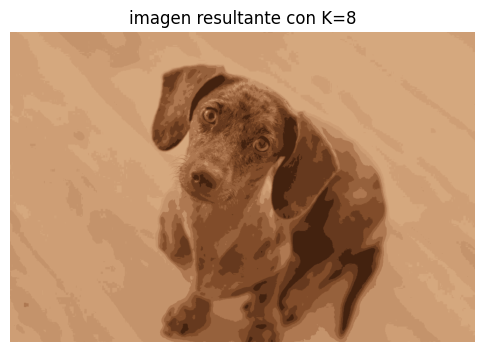

In [68]:
# pruebo la función con k=8, mostrando la imagen pero sin guardarla
resultado_k8 = kmeans_imagen(imagen_cuqui, K=8, mostrar=True, guardar=False)


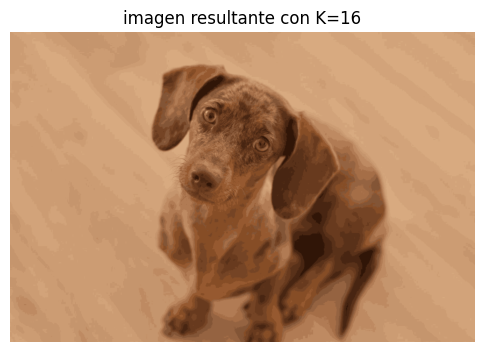

In [69]:
resultado_k16 = kmeans_imagen(imagen_cuqui, K=16, mostrar=True, guardar=False)

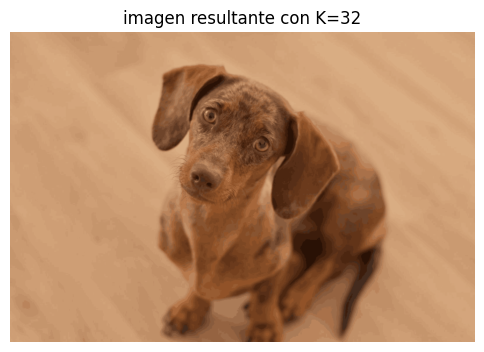

In [70]:
resultado_k32 = kmeans_imagen(imagen_cuqui, K=32, mostrar=True, guardar=False)